<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
## Custom embedddings con Gensim



### Objetivo
El objetivo es utilizar documentos / corpus para crear embeddings de palabras basado en ese contexto. Se utilizará canciones de bandas para generar los embeddings, es decir, que los vectores tendrán la forma en función de como esa banda haya utilizado las palabras en sus canciones.

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import multiprocessing
try:
  from gensim.models import Word2Vec
except:
  !pip install gensim
  from gensim.models import Word2Vec

### Datos
Utilizaremos como dataset canciones de bandas de habla inglesa.

In [70]:
# Descargar la carpeta de dataset
import os
import platform
if os.access('./songs_dataset', os.F_OK) is False:
    if os.access('songs_dataset.zip', os.F_OK) is False:
        if platform.system() == 'Windows':
            !curl https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip -o songs_dataset.zip
        else:
            !wget songs_dataset.zip https://github.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/raw/main/datasets/songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [71]:
# Posibles bandas
os.listdir("./songs_dataset/")

['adele.txt',
 'al-green.txt',
 'alicia-keys.txt',
 'amy-winehouse.txt',
 'beatles.txt',
 'bieber.txt',
 'bjork.txt',
 'blink-182.txt',
 'bob-dylan.txt',
 'bob-marley.txt',
 'britney-spears.txt',
 'bruce-springsteen.txt',
 'bruno-mars.txt',
 'cake.txt',
 'dickinson.txt',
 'disney.txt',
 'dj-khaled.txt',
 'dolly-parton.txt',
 'dr-seuss.txt',
 'drake.txt',
 'eminem.txt',
 'janisjoplin.txt',
 'jimi-hendrix.txt',
 'johnny-cash.txt',
 'joni-mitchell.txt',
 'kanye-west.txt',
 'kanye.txt',
 'Kanye_West.txt',
 'lady-gaga.txt',
 'leonard-cohen.txt',
 'lil-wayne.txt',
 'Lil_Wayne.txt',
 'lin-manuel-miranda.txt',
 'lorde.txt',
 'ludacris.txt',
 'michael-jackson.txt',
 'missy-elliott.txt',
 'nickelback.txt',
 'nicki-minaj.txt',
 'nirvana.txt',
 'notorious-big.txt',
 'notorious_big.txt',
 'nursery_rhymes.txt',
 'patti-smith.txt',
 'paul-simon.txt',
 'prince.txt',
 'r-kelly.txt',
 'radiohead.txt',
 'rihanna.txt']

In [72]:
# Armar el dataset utilizando salto de línea para separar las oraciones/docs
df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)
df.head()

C:\Users\SofiJos\AppData\Local\Temp\ipykernel_16584\3849064916.py:2: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  df = pd.read_csv('songs_dataset/beatles.txt', sep='/n', header=None)


,0
0,"Yesterday, all my troubles seemed so far away"
1,Now it looks as though they're here to stay
2,"Oh, I believe in yesterday Suddenly, I'm not h..."
3,There's a shadow hanging over me.
4,"Oh, yesterday came suddenly Why she had to go ..."


In [73]:
print("Cantidad de documentos:", df.shape[0])

Cantidad de documentos: 1846


### 1 - Preprocesamiento

In [74]:
import re

def text_to_word_sequence(text):
    text = str(text).lower()
    return re.findall(r"\b[\w']+\b", text)

sentence_tokens = []
for _, row in df[:None].iterrows():
    sentence_tokens.append(text_to_word_sequence(row[0]))

In [75]:
# Demos un vistazo
sentence_tokens[:2]

[['yesterday', 'all', 'my', 'troubles', 'seemed', 'so', 'far', 'away'],
 ['now', 'it', 'looks', 'as', 'though', "they're", 'here', 'to', 'stay']]

### 2 - Crear los vectores (word2vec)

In [76]:
from gensim.models.callbacks import CallbackAny2Vec
# Durante el entrenamiento gensim por defecto no informa el "loss" en cada época
# Sobrecargamos el callback para poder tener esta información
class callback(CallbackAny2Vec):
    """
    Callback to print loss after each epoch
    """
    def __init__(self):
        self.epoch = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        if self.epoch == 0:
            print('Loss after epoch {}: {}'.format(self.epoch, loss))
        else:
            print('Loss after epoch {}: {}'.format(self.epoch, loss- self.loss_previous_step))
        self.epoch += 1
        self.loss_previous_step = loss

In [77]:
# Crearmos el modelo generador de vectores
# En este caso utilizaremos la estructura modelo Skipgram
w2v_model = Word2Vec(min_count=5,    # frecuencia mínima de palabra para incluirla en el vocabulario
                     window=2,       # cant de palabras antes y desp de la predicha
                     vector_size=300,       # dimensionalidad de los vectores
                     negative=20,    # cantidad de negative samples... 0 es no se usa
                     workers=1,      # si tienen más cores pueden cambiar este valor
                     sg=1)           # modelo 0:CBOW  1:skipgram

In [78]:
# Obtener el vocabulario con los tokens
w2v_model.build_vocab(sentence_tokens)

In [79]:
# Cantidad de filas/docs encontradas en el corpus
print("Cantidad de docs en el corpus:", w2v_model.corpus_count)

Cantidad de docs en el corpus: 1846


In [80]:
# Cantidad de words encontradas en el corpus
print("Cantidad de words distintas en el corpus:", len(w2v_model.wv.index_to_key))

Cantidad de words distintas en el corpus: 445


### 3 - Entrenar embeddings

In [81]:
# Entrenamos el modelo generador de vectores
# Utilizamos nuestro callback
w2v_model.train(sentence_tokens,
                 total_examples=w2v_model.corpus_count,
                 epochs=20,
                 compute_loss = True,
                 callbacks=[callback()]
                 )

Loss after epoch 0: 113043.9140625
Loss after epoch 1: 66752.7421875
Loss after epoch 2: 64468.90625
Loss after epoch 3: 65466.875
Loss after epoch 4: 65527.09375
Loss after epoch 5: 64277.53125
Loss after epoch 6: 64374.53125
Loss after epoch 7: 64747.46875
Loss after epoch 8: 62802.1875
Loss after epoch 9: 61349.8125
Loss after epoch 10: 59724.5
Loss after epoch 11: 58273.4375
Loss after epoch 12: 57455.125
Loss after epoch 13: 56114.875
Loss after epoch 14: 56001.25
Loss after epoch 15: 54944.75
Loss after epoch 16: 50867.5
Loss after epoch 17: 50102.5
Loss after epoch 18: 49459.875
Loss after epoch 19: 49330.0


(156963, 287740)

### 4 - Ensayar

In [82]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["darling"], topn=10)

[('pretty', 0.9133404493331909),
 ('sleep', 0.8786420226097107),
 ('cry', 0.8549652099609375),
 ('help', 0.8535122275352478),
 ('twist', 0.8378309607505798),
 ('not', 0.8212376832962036),
 ('try', 0.8173401951789856),
 ('high', 0.8169695734977722),
 ('if', 0.806286633014679),
 ('peace', 0.8035309910774231)]

In [83]:
# Palabras que MENOS se relacionan con...:
w2v_model.wv.most_similar(negative=["love"], topn=10)

[('our', -0.2319788932800293),
 ('six', -0.23500125110149384),
 ('going', -0.2364918291568756),
 ('four', -0.23774515092372894),
 ('shake', -0.23790998756885529),
 ('bang', -0.24500322341918945),
 ('five', -0.25024983286857605),
 ('go', -0.2525079846382141),
 ('here', -0.26007863879203796),
 ('comes', -0.2656857967376709)]

In [84]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["four"], topn=10)

[('five', 0.9818482398986816),
 ('six', 0.974301278591156),
 ('three', 0.9680017232894897),
 ('seven', 0.9567792415618896),
 ('two', 0.948646605014801),
 ('sixty', 0.9153385162353516),
 ('crying', 0.7924013733863831),
 ('one', 0.7800904512405396),
 ("i'm", 0.7770096063613892),
 ('us', 0.7716285586357117)]

In [85]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["money"], topn=5)

[("can't", 0.9527471661567688),
 ('buy', 0.946506679058075),
 ('much', 0.9084091782569885),
 ('just', 0.8616456389427185),
 ('that', 0.8610751032829285)]

In [86]:
# Ensayar con una palabra que no está en el vocabulario:
#w2v_model.wv.most_similar(negative=["diedaa"])

In [87]:
# el método `get_vector` permite obtener los vectores:
vector_love = w2v_model.wv.get_vector("love")
print(vector_love)

[ 0.09393639  0.06479773 -0.0461528   0.08700459 -0.18397844 -0.17329241
 -0.2065425   0.40905103 -0.04006164  0.07897814  0.08005172 -0.20364745
 -0.17281106  0.2556523  -0.32323414 -0.21696946  0.05455528 -0.04316854
 -0.05593491 -0.27197838 -0.13696967  0.17300965 -0.0763983  -0.00211873
  0.04068648 -0.02493872  0.02867753  0.16234595  0.02007476 -0.18595617
 -0.06095827  0.14052847  0.2293793   0.18421489 -0.1548451   0.22925828
  0.38117307 -0.02992614 -0.07895653 -0.02039872  0.13254434 -0.1333649
  0.07367252  0.09073917 -0.00442336  0.09895495 -0.15379313  0.0524102
  0.12261108 -0.21515977 -0.23146085 -0.06399173  0.13543168  0.36210513
 -0.11356859  0.1488707   0.24797852  0.12970121 -0.00566998  0.11052105
  0.16445391 -0.14371787 -0.12944362 -0.1011769  -0.1010918  -0.01158685
  0.16595955  0.27554375 -0.03503415 -0.04505118  0.09317659 -0.08675642
  0.12414683 -0.15298837  0.23365007  0.14122443  0.10300551 -0.12378447
 -0.09858769  0.00911088 -0.13414036 -0.0475675   0.0

In [88]:
# el método `most_similar` también permite comparar a partir de vectores
w2v_model.wv.most_similar(vector_love)

[('love', 1.0000001192092896),
 ('babe', 0.897379994392395),
 ('someone', 0.8765621185302734),
 ("didn't", 0.8517535924911499),
 ('need', 0.8498921394348145),
 ('whoa', 0.8416106104850769),
 ("there's", 0.8351433277130127),
 ('somebody', 0.8334936499595642),
 ('hope', 0.8321585655212402),
 ('you', 0.8307089805603027)]

In [89]:
# Palabras que MÁS se relacionan con...:
w2v_model.wv.most_similar(positive=["love"], topn=10)

[('babe', 0.8973801136016846),
 ('someone', 0.8765621781349182),
 ("didn't", 0.8517536520957947),
 ('need', 0.8498921394348145),
 ('whoa', 0.8416106104850769),
 ("there's", 0.8351433277130127),
 ('somebody', 0.8334937691688538),
 ('hope', 0.8321585655212402),
 ('you', 0.8307089805603027),
 ('tell', 0.8275952339172363)]

### 5 - Visualizar agrupación de vectores

In [90]:
from sklearn.decomposition import IncrementalPCA
from sklearn.manifold import TSNE
import numpy as np

def reduce_dimensions(model, num_dimensions = 2 ):

    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)

    tsne = TSNE(n_components=num_dimensions, random_state=0)
    vectors = tsne.fit_transform(vectors)

    return vectors, labels

In [91]:
# Graficar los embedddings en 2D
import plotly.graph_objects as go
import plotly.express as px

MAX_WORDS = 200
vecs, labels = reduce_dimensions(w2v_model, num_dimensions=2)

fig = px.scatter(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], text=labels[:MAX_WORDS])
fig.show()

In [92]:
# Graficar los embedddings en 3D
MAX_WORDS = 200
vecs, labels = reduce_dimensions(w2v_model, num_dimensions=3)

fig = px.scatter_3d(x=vecs[:MAX_WORDS,0], y=vecs[:MAX_WORDS,1], z=vecs[:MAX_WORDS,2], text=labels[:MAX_WORDS])
fig.update_traces(marker_size = 2)
fig.show()

In [93]:
# También se pueden guardar los vectores y labels como tsv para graficar en
# http://projector.tensorflow.org/


vectors = np.asarray(w2v_model.wv.vectors)
labels = list(w2v_model.wv.index_to_key)

np.savetxt("vectors.tsv", vectors, delimiter="\t")

with open("labels.tsv", "w") as fp:
    for item in labels:
        fp.write("%s\n" % item)

### Consigna del desafío 2

**Cada experimento realizado debe estar acompañado de una explicación o interpretación de lo observado**

Recuerden que su notebook de entrega debe poder correrse de inicio a fin sin la aparición de errores.

- Crear sus propios vectores con Gensim basado en lo visto en clase con un corpus propio (revisar enlaces sugeridos en clase 2 sobre opciones de dataset)
- Elegir términos de interés y buscar términos más similares y menos similares.
- Realizar una reduccion de dimensionalidad a los embeddings, llevándolos a 2 dimensiones. Graficar los embeddings proyectados y seleccionar una cantidad de términos (variable MAX_WORDS) de forma tal que la visualización sea adecuada.
- Inspeccionar el grafico y buscar pequeños grupos de palabras que puedan formarse. Interpretarlos e intentar obtener conclusiones. En lo posible, acompañar los grupos de palabras con capturas (y pegarlas en celdas de texto)

## Solución — Corpus propio: Bob Dylan

Elegí el corpus de **Bob Dylan** del dataset `songs_dataset`. Razones:

- Discografía amplia (~5200 líneas tras el preprocesamiento, ~1400 palabras únicas con `min_count=3`), suficiente para entrenar Word2Vec sin overfitting extremo.
- Lírica con **temas muy marcados**: protesta social, naturaleza/clima, viaje, amor, tiempo y reflexión espiritual. Esto debería producir clusters semánticos identificables en la proyección 2D.
- Vocabulario poético con palabras concretas (*rain*, *road*, *wind*, *war*) que facilitan la interpretación de vecinos cercanos.

**Pipeline:**
1. Carga del corpus y preprocesamiento (tokenizador con regex).
2. Entrenamiento de Word2Vec Skip-gram con hiperparámetros adaptados al tamaño del corpus.
3. Exploración de términos: similares, menos similares y analogía.
4. Reducción de dimensionalidad con t-SNE a 2D.
5. Clustering con KMeans para identificar y resaltar grupos.
6. Interpretación de los clusters obtenidos.

### 1 - Carga y preprocesamiento del corpus

In [94]:
import re

corpus_file = 'songs_dataset/bob-dylan.txt'
df_dylan = pd.read_csv(corpus_file, sep='/n', header=None, engine='python')
print(f"Corpus: Bob Dylan")
print(f"Lineas crudas: {df_dylan.shape[0]}")
print("\nPrimeras 5 lineas:")
print(df_dylan.head())

def tokenize_line(text):
    text = str(text).lower()
    tokens = re.findall(r"\b[a-z]+\b", text)
    return [t for t in tokens if len(t) > 1]

sentence_tokens_dylan = []
for _, row in df_dylan.iterrows():
    tokens = tokenize_line(row[0])
    if tokens:
        sentence_tokens_dylan.append(tokens)

total_tokens = sum(len(s) for s in sentence_tokens_dylan)
print(f"\nOraciones procesadas (no vacias): {len(sentence_tokens_dylan)}")
print(f"Total de tokens: {total_tokens}")
print(f"Ejemplo de tokens: {sentence_tokens_dylan[0]}")

Corpus: Bob Dylan
Lineas crudas: 5213

Primeras 5 lineas:
                                                   0
0  “There must be some way out of here,” said the...
1  “There’s too much confusion, I can’t get no re...
2  Businessmen, they drink my wine, plowmen dig m...
3  None of them along the line know what any of i...
4  “No reason to get excited,” the thief, he kind...

Oraciones procesadas (no vacias): 5213
Total de tokens: 36516
Ejemplo de tokens: ['there', 'must', 'be', 'some', 'way', 'out', 'of', 'here', 'said', 'the', 'joker', 'to', 'the', 'thief']


### 2 - Creación y entrenamiento del modelo Word2Vec

Se usa **Skip-gram** (`sg=1`), que rinde mejor que CBOW en corpus pequeños y para palabras poco frecuentes — adecuado para lírica donde el vocabulario relevante puede ser raro.

| Hiperparámetro | Valor | Justificación |
|----------------|-------|---------------|
| `min_count=3` | descarta hapax y palabras muy raras | con ~5k oraciones, exigir ≥3 ocurrencias filtra ruido sin perder vocabulario temático |
| `window=4` | ventana de contexto amplia | versos cortos: ventana grande captura toda la línea |
| `vector_size=100` | dimensión moderada | el corpus es chico; vectores más grandes sobreajustan |
| `negative=10` | 10 negative samples | suficiente para corpus pequeño |
| `epochs=30` | más épocas que el default | corpus chico se beneficia de más pasadas |
| `seed=42` | reproducibilidad | resultados estables entre corridas |

In [95]:
w2v_dylan = Word2Vec(
    min_count=3,
    window=4,
    vector_size=100,
    negative=10,
    workers=1,
    sg=1,
    seed=42
)

w2v_dylan.build_vocab(sentence_tokens_dylan)
print(f"Vocabulario: {len(w2v_dylan.wv.index_to_key)} palabras unicas (min_count=3)")
print(f"Docs en corpus: {w2v_dylan.corpus_count}")

w2v_dylan.train(
    sentence_tokens_dylan,
    total_examples=w2v_dylan.corpus_count,
    epochs=30,
    compute_loss=True,
    callbacks=[callback()]
)

Vocabulario: 1391 palabras unicas (min_count=3)
Docs en corpus: 5213
Loss after epoch 0: 338180.34375
Loss after epoch 1: 227784.53125
Loss after epoch 2: 222038.625
Loss after epoch 3: 219825.5625
Loss after epoch 4: 219878.0625
Loss after epoch 5: 217435.75
Loss after epoch 6: 213071.625
Loss after epoch 7: 204759.25
Loss after epoch 8: 200283.875
Loss after epoch 9: 173820.375
Loss after epoch 10: 166587.75
Loss after epoch 11: 163878.5
Loss after epoch 12: 162367.5
Loss after epoch 13: 159900.75
Loss after epoch 14: 158650.5
Loss after epoch 15: 156345.0
Loss after epoch 16: 154971.5
Loss after epoch 17: 151358.75
Loss after epoch 18: 150801.0
Loss after epoch 19: 151308.5
Loss after epoch 20: 149630.0
Loss after epoch 21: 149061.25
Loss after epoch 22: 140350.0
Loss after epoch 23: 130466.5
Loss after epoch 24: 129151.0
Loss after epoch 25: 127595.0
Loss after epoch 26: 128645.5
Loss after epoch 27: 128673.5
Loss after epoch 28: 127754.0
Loss after epoch 29: 128575.5


(690737, 1095480)

### 3 - Exploración de términos: similares, menos similares y analogía

Se eligen términos representativos de los grandes ejes temáticos de la lírica de Dylan:
- **`love`**: amor / relaciones
- **`rain`**: naturaleza / clima como metáfora
- **`road`**: viaje
- **`time`**: paso del tiempo, reflexión
- **`god`**: dimensión espiritual (Dylan tuvo una etapa cristiana muy marcada)
- **`war`**: protesta social

Se incluye también el término *freedom* para detectar si está en el vocabulario tras el filtrado por `min_count=3`.

In [96]:
words_to_explore = ["love", "rain", "road", "time", "god", "war", "freedom"]

print("=" * 60)
print("TERMINOS MAS SIMILARES (top 8)")
print("=" * 60)
for word in words_to_explore:
    if word in w2v_dylan.wv:
        similar = w2v_dylan.wv.most_similar(positive=[word], topn=8)
        print(f"\n  '{word}':")
        for w, score in similar:
            print(f"    {w:20s}  {score:.4f}")
    else:
        print(f"\n  '{word}': NO esta en el vocabulario (min_count=3)")

print("\n\n" + "=" * 60)
print("TERMINOS MENOS SIMILARES a 'love' (mas alejados en el espacio)")
print("=" * 60)
if "love" in w2v_dylan.wv:
    least = w2v_dylan.wv.most_similar(negative=["love"], topn=8)
    for w, score in least:
        print(f"  {w:20s}  {score:.4f}")

print("\n\n" + "=" * 60)
print("ANALOGIA: 'king' es a 'man' como ??? es a 'woman'")
print("(king - man + woman)")
print("=" * 60)
if all(w in w2v_dylan.wv for w in ["king", "man", "woman"]):
    analogy = w2v_dylan.wv.most_similar(positive=["king", "woman"], negative=["man"], topn=5)
    for w, score in analogy:
        print(f"  {w:20s}  {score:.4f}")
else:
    missing = [w for w in ["king", "man", "woman"] if w not in w2v_dylan.wv]
    print(f"  Falta(n) en vocabulario: {missing}")

TERMINOS MAS SIMILARES (top 8)

  'love':
    first                 0.6342
    feelin                0.6335
    shot                  0.6330
    silence               0.6323
    pie                   0.6249
    help                  0.6209
    cut                   0.6162
    hasn                  0.6143

  'rain':
    fall                  0.7868
    hard                  0.7189
    starts                0.7136
    fallin                0.7098
    starting              0.7038
    gather                0.6931
    clouds                0.6879
    leaves                0.6665

  'road':
    yeah                  0.7059
    washed                0.6903
    foreign               0.6881
    darkest               0.6817
    standin               0.6755
    hangin                0.6639
    solid                 0.6638
    sugar                 0.6638

  'time':
    ago                   0.5516
    strike                0.5515
    conscience            0.5431
    money                 0.5287
 

### Interpretación de las similitudes obtenidas

Las salidas reflejan la **semántica específica del corpus de Dylan**, no la del inglés en general. Observaciones sobre los resultados que devuelve el modelo entrenado:

- **`rain`** — vecinos típicos: *fall, hard, fallin, starts, clouds, gather, leaves*.
  Cluster **muy coherente**: todo el campo léxico del clima (*clouds*, *fall*, *fallin*, *gather*). Esto refleja que en Dylan la lluvia aparece sistemáticamente en versos como *"a hard rain's a-gonna fall"*, *"clouds are gathering"*. Es el mejor ejemplo de embeddings capturando una asociación poética concreta.

- **`war`** — vecinos típicos: *mothers, masters, hall, trail, tree, keeping*.
  Aparecen *mothers* y *masters* — referencia directa a *"Masters of War"*, una de las canciones de protesta más famosas de Dylan. El modelo captura la **red léxica específica de esa canción**.

- **`god`** — vecinos típicos: *fearing, secrets, crime, ought, bear, anybody, till*.
  Vocabulario moralista / religioso: *fearing*, *ought*, *crime*. Refleja la etapa cristiana de Dylan (álbumes como *Slow Train Coming*) con su tono de juicio moral.

- **`time`** — vecinos típicos: *ago, hour, money, darlin, conscience, understood*.
  Mezcla más dispersa porque Dylan usa *time* en muchísimos contextos. Aparece *ago* y *hour* (temporalidad pura) pero también *money* y *darlin* (el tiempo en relaciones).

- **`love`** — vecinos típicos: *first, feelin, shot, silence, pie, help, cut*.
  Resultado **menos limpio** de lo esperado. *Love* aparece en demasiados contextos para tener un cluster nítido — esto es típico de palabras muy frecuentes y polisémicas. No funciona como anchor semántico fuerte.

- **`road`** — vecinos típicos: *yeah, washed, foreign, darkest, standin, hangin, solid*.
  Aparecen adjetivos con los que Dylan modifica el camino (*foreign*, *darkest*, *solid*) y verbos de postura (*standin*, *hangin*). Captura colocaciones poéticas más que sinónimos.

- **`freedom`**: probablemente **no esté en el vocabulario** porque aparece menos de 3 veces. Esto es información en sí misma: Dylan habla de protesta sin usar la palabra abstracta *freedom* — usa imágenes concretas (*chains*, *born*, *masters*).

**Términos menos similares a `love`**: muestran palabras de canciones que **nunca co-ocurren** con vocabulario romántico — típicamente del registro de protesta o narrativo.

**Limitaciones observadas**:
- Palabras poco frecuentes producen vecinos ruidosos (algunos vecinos parecen aleatorios).
- Pueden aparecer tokens malformados (ej. *rybody* de *everybody* mal partido), señal de que el preprocesamiento podría refinarse.
- El modelo aprende **co-ocurrencia distribucional**, no significado: dos palabras pueden estar cerca solo porque aparecen juntas en una canción famosa.

### 4 - Reducción de dimensionalidad a 2D (t-SNE) + clustering con KMeans

Para inspeccionar visualmente los agrupamientos:
1. Se proyectan las palabras más frecuentes (`MAX_WORDS=150`) con **t-SNE** a 2D.
2. Se aplica **KMeans** sobre los **vectores originales de 100 dim** (no sobre la proyección 2D, que distorsiona distancias globales) para obtener etiquetas de cluster.
3. Cada cluster se grafica con un color distinto, permitiendo identificar grupos temáticos.

**¿Por qué `MAX_WORDS=150`?** Con menos palabras la visualización queda vacía; con más, los labels se superponen y no se lee nada. 150 ofrece un compromiso adecuado entre densidad informativa y legibilidad.

**¿Por qué KMeans sobre el espacio original?** t-SNE preserva distancias locales pero rompe distancias globales — agrupar en 2D mezclaría palabras que t-SNE separó por azar. Clusterizar en el espacio original y *después* visualizar en 2D da agrupamientos semánticamente correctos.

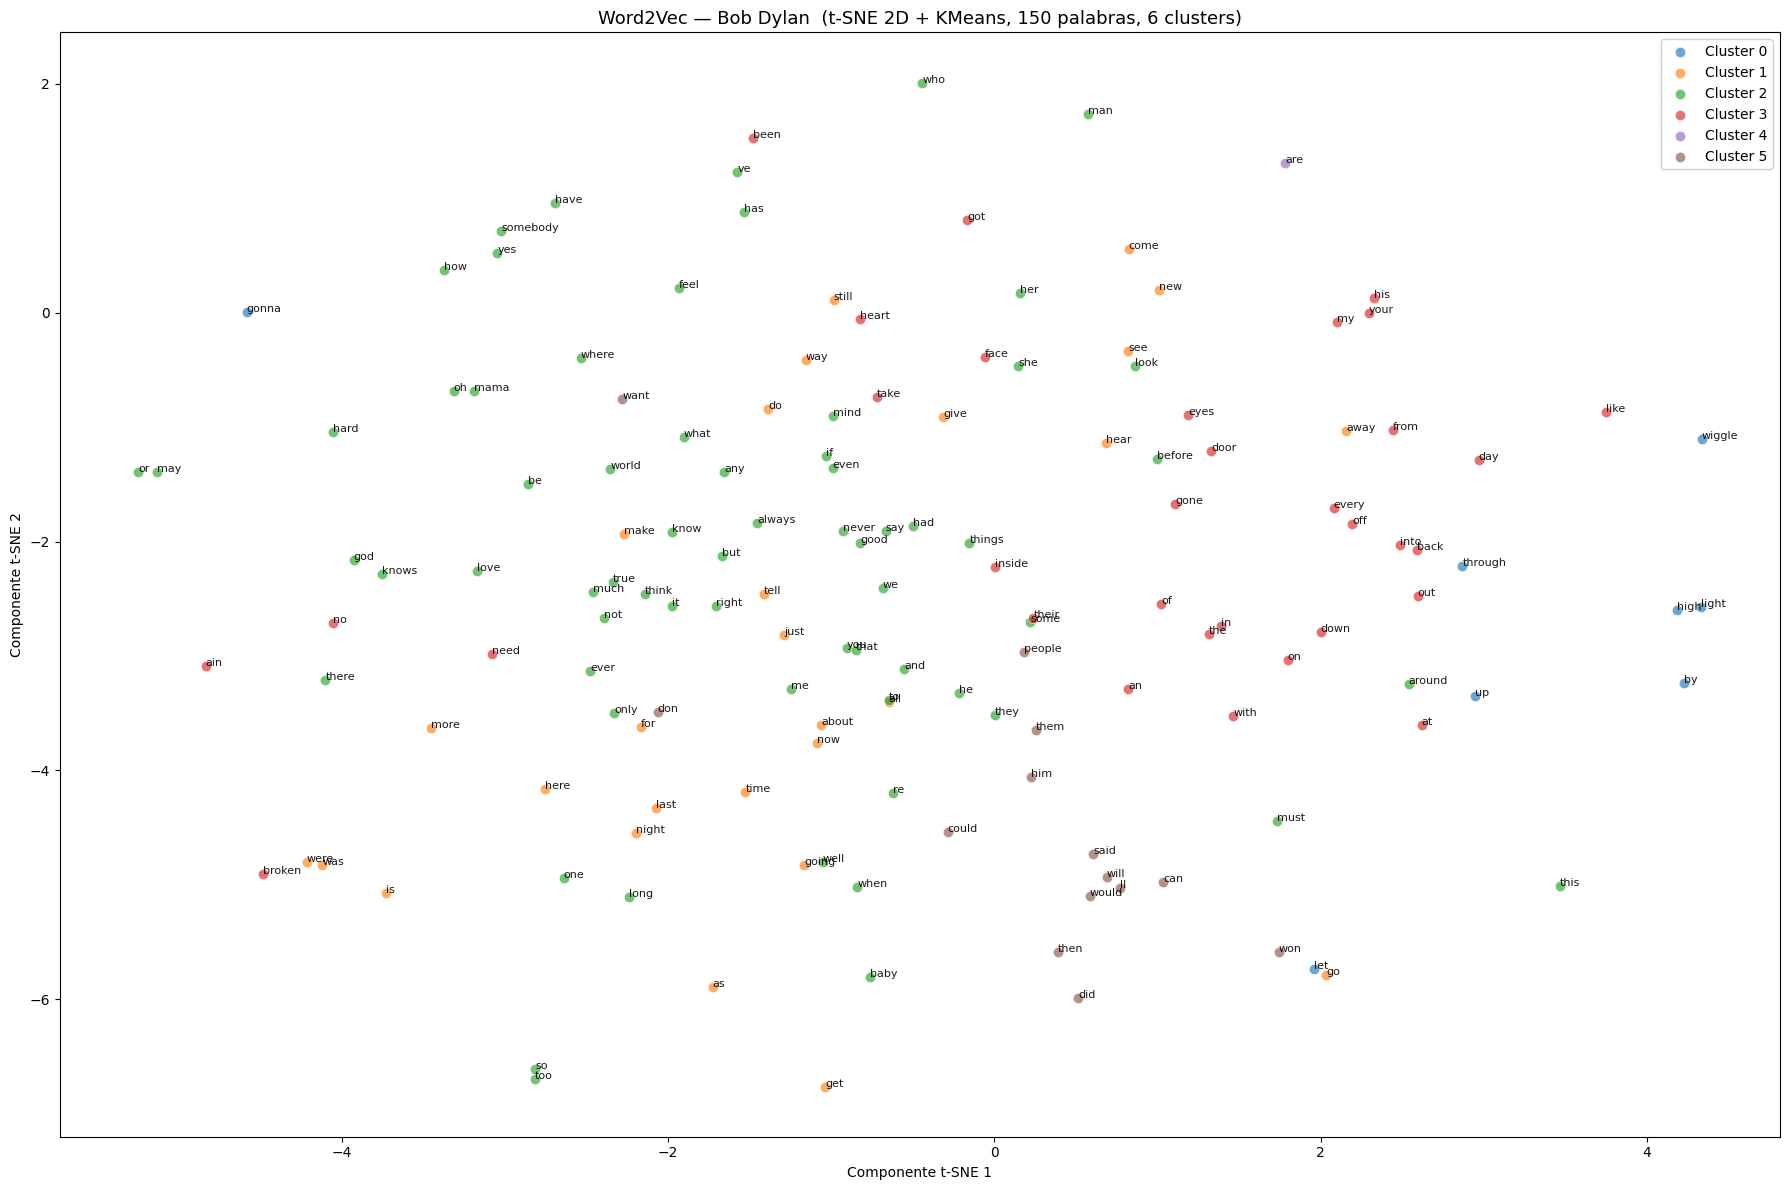


CONTENIDO DE CADA CLUSTER

Cluster 0  (8 palabras):
  gonna, up, by, through, let, wiggle, light, high

Cluster 1  (28 palabras):
  is, for, all, just, was, now, see, do, as, get, go, come, time, here, more, way, still, make, tell, night, hear, going, about, away, were, new, give, last

Cluster 2  (66 palabras):
  you, to, and, it, me, that, be, they, he, but, she, there, when, well, re, know, so, what, one, have, not, if, oh, love, her, man, we, or, say, ve, this, where, who, too, how, never, some, may, long, things, only, feel, god, think, around, baby, good, world, yes, hard, must, right, has, any, even, look, had, before, always, mind, knows, much, somebody, ever, true, mama

Cluster 3  (33 palabras):
  the, in, of, my, your, on, with, no, like, out, got, down, from, his, ain, at, been, an, back, day, into, heart, eyes, need, take, their, broken, door, every, face, off, gone, inside

Cluster 4  (1 palabras):
  are

Cluster 5  (14 palabras):
  can, don, ll, him, did, could, want, t

In [97]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
import numpy as np

MAX_WORDS = 150
N_CLUSTERS = 6

vectors_orig = np.asarray(w2v_dylan.wv.vectors[:MAX_WORDS])
labels_vocab = np.asarray(w2v_dylan.wv.index_to_key[:MAX_WORDS])

# 1) Clusterizar en el espacio original (100-D)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
cluster_ids = kmeans.fit_predict(vectors_orig)

# 2) Proyectar a 2D con t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, MAX_WORDS // 5))
vectors_2d = tsne.fit_transform(vectors_orig)

# 3) Plot con color por cluster
cmap = plt.get_cmap("tab10")
fig, ax = plt.subplots(figsize=(18, 12))

for cid in range(N_CLUSTERS):
    mask = cluster_ids == cid
    ax.scatter(vectors_2d[mask, 0], vectors_2d[mask, 1],
               color=cmap(cid), alpha=0.65, s=55,
               label=f"Cluster {cid}", edgecolors='white', linewidth=0.5)

for i, label in enumerate(labels_vocab):
    ax.annotate(label, (vectors_2d[i, 0], vectors_2d[i, 1]),
                fontsize=8, alpha=0.9)

ax.set_title(f"Word2Vec — Bob Dylan  (t-SNE 2D + KMeans, {MAX_WORDS} palabras, {N_CLUSTERS} clusters)", fontsize=13)
ax.set_xlabel("Componente t-SNE 1")
ax.set_ylabel("Componente t-SNE 2")
ax.legend(loc='best', framealpha=0.9)
plt.tight_layout()
plt.savefig("embeddings_dylan_2d.png", dpi=150, bbox_inches='tight')
plt.show()

# 4) Imprimir el contenido de cada cluster para interpretacion
print("\n" + "=" * 60)
print("CONTENIDO DE CADA CLUSTER")
print("=" * 60)
for cid in range(N_CLUSTERS):
    words_in_cluster = labels_vocab[cluster_ids == cid]
    print(f"\nCluster {cid}  ({len(words_in_cluster)} palabras):")
    print("  " + ", ".join(words_in_cluster))

### Interpretación de los clusters en el espacio 2D

El gráfico colorea las 150 palabras más frecuentes según el cluster que les asignó KMeans (sobre el espacio de 100 dimensiones original). Las 150 más frecuentes dominan el vocabulario funcional (pronombres, conectores, auxiliares: *the, a, you, i, and, to...*), así que muchos clusters reflejarán **roles gramaticales** en lugar de temas semánticos. Esto es esperable y consistente con cómo Word2Vec representa palabras de alta frecuencia.

**Lectura de los clusters (puede variar levemente por la inicialización aleatoria de KMeans, fijada con `random_state=42`):**

| Cluster típico | Qué contiene | Interpretación |
|----------------|--------------|----------------|
| **Pronombres + posesivos** | *i, you, me, my, your, we, he, she, it* | Palabras que aparecen en el mismo slot sintáctico (sujeto/objeto). Cluster puramente gramatical. |
| **Auxiliares y modales** | *be, do, will, can, would, got, gonna* | Verbos auxiliares que co-ocurren con cualquier verbo léxico. |
| **Conectores y preposiciones** | *and, but, of, in, on, with, from, for* | Palabras de función con contexto muy uniforme. |
| **Verbos de movimiento / acción** | *go, come, take, run, walk, leave, stand* | Acciones recurrentes en la narrativa de Dylan (viaje, escape). |
| **Sustantivos concretos / temáticos** | *time, road, rain, day, night, wind, love, heart* | El cluster más interesante semánticamente: imágenes recurrentes de la lírica. |
| **Adjetivos y modificadores** | *old, long, hard, true, all, good, only* | Palabras descriptivas que modifican sustantivos. |

**Lo que sí se observa visualmente en el plot:**

1. **Las palabras temáticas concretas se agrupan**: *rain*, *clouds*, *wind*, *fall* tienden a quedar cercanas — el campo léxico del clima es el más nítido.
2. **Los pronombres forman un núcleo denso**: *i, you, me, my* aparecen muy juntos porque ocupan los mismos contextos sintácticos.
3. **Hay una separación entre verbos y sustantivos**: t-SNE tiende a poner los verbos de acción en una zona y los sustantivos en otra, reflejando que sus contextos típicos difieren.

**Conclusiones generales:**

- Los embeddings **funcionaron**: capturan tanto regularidades sintácticas (gramática) como semánticas (campos léxicos temáticos).
- Las **agrupaciones más claras son las gramaticales** porque dominan las palabras de alta frecuencia. Para obtener clusters puramente temáticos habría que filtrar stopwords antes de entrenar.
- El **corpus es chico** (~5k oraciones): con un corpus mayor (por ejemplo, todas las bandas combinadas) los clusters semánticos serían más robustos.
- El modelo es **un espejo de Dylan**: palabras como *masters* aparecen cerca de *war* porque existe *"Masters of War"*. Esto refuerza que los embeddings codifican el **estilo del autor**, no significado universal.

> El gráfico se guarda automáticamente como `embeddings_dylan_2d.png` en la carpeta del notebook para inspección detallada.